In [1]:
import numpy as np
import matplotlib.pyplot as plt

from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate

In [2]:
def residual_H(H, px1, px2, type = "One image"):
    N = px1.shape[1]
    
    # Convert to homogeneous coordinates
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2] # Dehomogenization
    # Sum over ALL dimensions (both x/y and all N points)
    sum_d12 = np.sum((p12 - px2) ** 2) 

    if type == "One image":
        # Equation 5.1 from the textbook
        res_H = np.sqrt(1 / (2 * N) * sum_d12)
        
    else:
        # Backward: H⁻¹ · px2 → px1
        p21 = np.linalg.inv(H) @ h2
        p21 = p21[:2] / p21[2] # Dehomogenization
        sum_d21 = np.sum((p21 - px1) ** 2)
        
        # Symmetric transfer error
        res_H = np.sqrt(1 / (4 * N) * (sum_d12 + sum_d21))
        
    return res_H

def residual_F(px1, px2, F, type = None):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    if type is not None:
        return d2_sym
    sum_d2_sym = np.sum(d2_sym)
    total_error = np.sqrt(1 / (2*N) * sum_d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=1.5, cam2_ty=0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42,
    dispersion = None
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    xs = rng.uniform(-x_range, x_range, n_points)
    ys = rng.uniform(-y_range, y_range, n_points)
    if dispersion is not None:
        # 1. Generate random angles between 0 and 2π
        angles = rng.uniform(0, 2 * np.pi, n_points)
        
        # 2. Generate random radii
        # CRITICAL: You must take the square root of the random uniform value!
        # If you don't, your points will cluster heavily in the exact center.
        radii = dispersion * np.sqrt(rng.uniform(0, 1, n_points))
        
        # 3. Convert polar coordinates (radius, angle) back to Cartesian (X, Y)
        xs = radii * np.cos(angles)
        ys = radii * np.sin(angles)

    if scene_type == 'planar':
        zs = np.full(n_points, z_min)
    else:
        lo, hi = min(z_min, z_max), max(z_min, z_max)
        zs = rng.uniform(lo, hi, n_points)

    pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
    }

def _rot_err(R_est, R_ref):
    tr = np.trace(R_est.T @ R_ref)
    return np.degrees(np.arccos(np.clip((tr - 1) / 2, -1, 1)))


def _trans_err(t_est, t_ref):
    u = t_est / (np.linalg.norm(t_est) + 1e-12)
    v = t_ref / (np.linalg.norm(t_ref) + 1e-12)
    return np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), 0, 1)))

def _trans_mag_err(t_est, t_ref):
    return np.linalg.norm(t_ref - t_est)

def get_angles_from_matrix(R):
    # Extract ry (theta)
    # Note: this assumes the matrix is not in a "Gimbal Lock" state (ry != 90 or -90 deg)
    ry = np.arcsin(-R[2, 0])
    
    # Extract rx (phi)
    rx = np.arctan2(R[2, 1], R[2, 2])
    
    # Extract rz (psi)
    rz = np.arctan2(R[1, 0], R[0, 0])
    
    # Convert from radians to degrees
    return np.degrees([rx, ry, rz])

# Generate scene

In [3]:
# 1 Génération de la scène 
Nb_pts = 50
num_iterations = Nb_pts +1
res_F = np.full(num_iterations, np.nan)
scene_data = make_scene(n_points=50, outlier_ratio=0, noise_sigma=1)
count = 8
pts3d_vis = scene_data['pts3d']
px1_vis = scene_data['px1']
px2_vis = scene_data['px2']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
R_true = scene_data['R_rel']
t_true = scene_data['t_rel']
rng_noise = np.random.default_rng(1)
px1_vis = px1_vis# + rng_noise.normal(0, 1, px1_vis.shape)
px1_vis_main = px1_vis
px2_vis = px2_vis# + rng_noise.normal(0, 1, px2_vis.shape)
px2_vis_main = px2_vis
num_points = px1_vis_main.shape[1]
shuffled_indices = np.random.permutation(num_points)
for i in range(8, Nb_pts + 1):
    
    current_indices = shuffled_indices[:i]
    
    # Slice the main arrays using these indices
    px1_vis = px1_vis_main[:, current_indices]
    px2_vis = px2_vis_main[:, current_indices]
    pts3d = pts3d_vis[:, current_indices]
    
    ransac_solver_F = RANSAC(
    s=8, 
    score_fct=score_F_RANSAC,
    model_fct=eight_point, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d[:, mask]
    res_F[i] = residual_F(px1_vis_main, px2_vis_main, F_Ransac)

# Plot Residual error vs number of points

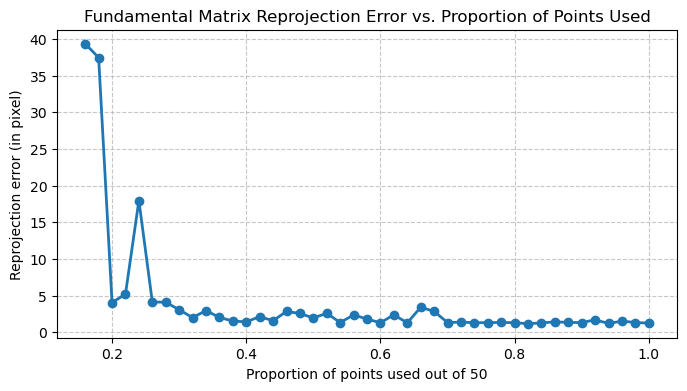

In [4]:
residuals = res_F

# 2. Create an X-axis array representing the number of points (0 to 50)
n_points = np.arange(len(residuals))

# 3. Set up the plot
plt.figure(figsize=(8, 4))

# Plot the data. Matplotlib ignores the NaNs at indices 0-7!
plt.plot(n_points/50, residuals, marker='o', linestyle='-', linewidth=2)
# 4. Add labels and styling to make it look professional for analysis
plt.title("Fundamental Matrix Reprojection Error vs. Proportion of Points Used")
plt.xlabel("Proportion of points used out of 50")
plt.ylabel("Reprojection error (in pixel)")
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Display the plot
plt.show()

In [5]:
# 1 Génération de la scène 
Nb_pts = 50
num_iterations = Nb_pts +1
res_H = np.full(num_iterations, np.nan)
scene_data = make_scene(n_points=50, outlier_ratio=0, noise_sigma=1, scene_type="planar")
count = 8
pts3d_vis = scene_data['pts3d']
px1_vis = scene_data['px1']
px2_vis = scene_data['px2']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
R_true = scene_data['R_rel']
t_true = scene_data['t_rel']
rng_noise = np.random.default_rng(1)
px1_vis = px1_vis# + rng_noise.normal(0, 1, px1_vis.shape)
px1_vis_main = px1_vis
px2_vis = px2_vis# + rng_noise.normal(0, 1, px2_vis.shape)
px2_vis_main = px2_vis
num_points = px1_vis_main.shape[1]

shuffled_indices = np.random.permutation(num_points)
for i in range(4, Nb_pts + 1):
    
    current_indices = shuffled_indices[:i]
    
    # Slice the main arrays using these indices
    px1_vis = px1_vis_main[:, current_indices]
    px2_vis = px2_vis_main[:, current_indices]
    pts3d = pts3d_vis[:, current_indices]
    
    ransac_solver_H = RANSAC(
    s=4, 
    score_fct=score_H_RANSAC,
    model_fct=homography, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d[:, mask]
    res_H[i] = residual_H(H_Ransac, px1_vis_main, px2_vis_main, type = "else")

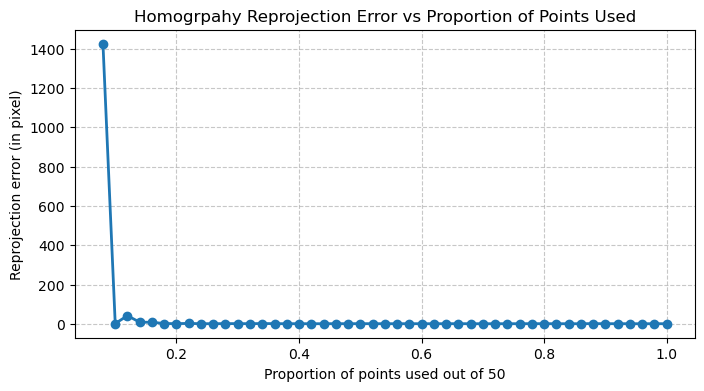

In [6]:
residuals = res_H

# 2. Create an X-axis array representing the number of points (0 to 50)
n_points = np.arange(len(residuals))

# 3. Set up the plot
plt.figure(figsize=(8, 4))

# Plot the data. Matplotlib ignores the NaNs at indices 0-7!
plt.plot(n_points/50, residuals, marker='o', linestyle='-', linewidth=2)
#plt.plot(n_points, R_error, label='Rotation Error (rad)', marker='s', linestyle='--')
#plt.plot(n_points, t_error, label='Translation Error', marker='^', linestyle='-.')
#plt.axhline(y=1.75, color='red', linestyle='--', linewidth=2, label='Noise Floor ($\sigma=1$)')
# 4. Add labels and styling to make it look professional for analysis
plt.title("Homogrpahy Reprojection Error vs Proportion of Points Used")
plt.xlabel("Proportion of points used out of 50")
plt.ylabel("Reprojection error (in pixel)")
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the X-axis shows integer ticks (since you can't have a fraction of a point)

# 5. Display the plot
plt.show()

# Histogram of reprojection error (Sampson distance)

In [7]:
def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    return d_samp

Nb_pts = 10000
res_F = np.full((1, Nb_pts + 1), np.nan)
scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=1, seed = 43)
        
pts3d_vis = scene_data['pts3d']
px1_vis = scene_data['px1']
px2_vis = scene_data['px2']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
#rng_noise = np.random.default_rng(1)
#px1_vis = px1_vis + rng_noise.normal(0, 1, px1_vis.shape)
#px1_vis_main = px1_vis
#px2_vis = px2_vis + rng_noise.normal(0, 1, px2_vis.shape)
#px2_vis_main = px2_vis

ransac_solver_F = RANSAC(
    s=8, 
    score_fct=score_F_RANSAC,
    model_fct=eight_point, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
F_Ransac, mask = ransac_solver_F.execute_RANSAC()
clean_px1 = px1_vis[:, mask]
clean_px2 = px2_vis[:, mask]
clean_p3d = pts3d_vis[:, mask]
d_samp = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

#7 Estrimate the projection matrix
P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
t2_hat = s*t2_norm
res_F = residual_F(clean_px1, clean_px2, F_Ransac, type= 1)
# Total symmetric reprojection error




KeyboardInterrupt: 

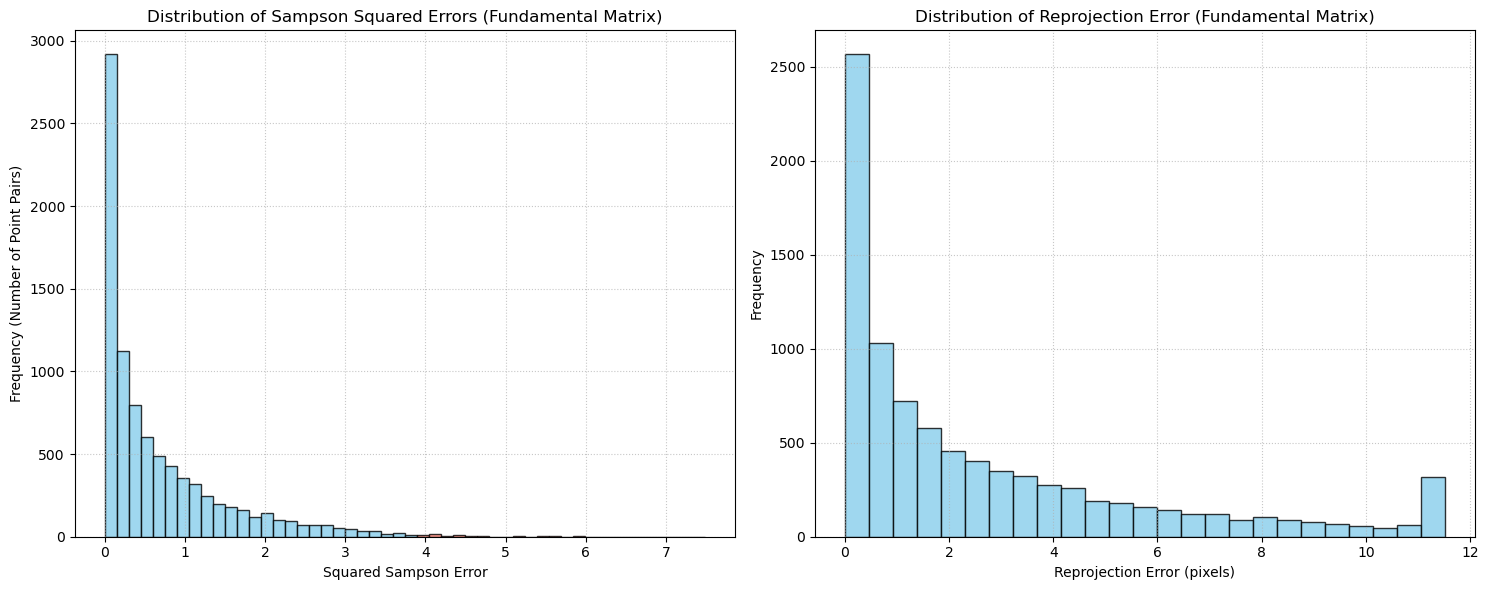

In [ ]:
threshold = 3.84
max_plot_val = threshold * 3

# Create a figure with 1 row and 2 columns, adjusting the width (15) and height (6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Sampson Squared Errors (Left) ---
counts1, bins1, patches1 = ax1.hist(
    np.clip(d_samp, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

# Color the bars that fall past the threshold red
for count, bin_edge, patch in zip(counts1, bins1, patches1):
    if bin_edge > threshold:
         patch.set_facecolor('salmon')
            
# Optional: Draw the decision boundary
# ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax1.set_title("Distribution of Sampson Squared Errors (Fundamental Matrix)")
ax1.set_xlabel("Squared Sampson Error")
ax1.set_ylabel("Frequency (Number of Point Pairs)")
# ax1.legend() # Uncomment if using the axvline above
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: Reprojection Error (Right) ---
counts2, bins2, patches2 = ax2.hist(
    np.clip(res_F, 0, max_plot_val), 
    bins=25, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

ax2.set_title("Distribution of Reprojection Error (Fundamental Matrix)")
ax2.set_xlabel("Reprojection Error (pixels)")
ax2.set_ylabel("Frequency")
# ax2.legend() 
ax2.grid(True, linestyle=':', alpha=0.7)

# tight_layout prevents the titles and labels from overlapping
plt.tight_layout()
plt.show()

# Effect of noise on the estimation of R and t, and other parameters

In [ ]:
Nb_pts = 200
noise_sigmas = np.linspace(0, 4, 21)
num_iterations = len(noise_sigmas)

# 1. FIXED: Initialize as 1D arrays matching the length of noise_sigmas
res_F = np.full(num_iterations, np.nan)
R_error = np.full(num_iterations, np.nan)
t_error = np.full(num_iterations, np.nan)
Repro_error = np.full(num_iterations, np.nan)
Ransac_mask = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
r_est = np.full((num_iterations, 3), np.nan)
r_true = np.full((num_iterations, 3), np.nan)
count = 0
for i in noise_sigmas:
    scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=i)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    r_true[count, :] = get_angles_from_matrix(R_true)
    r_est[count, :] = get_angles_from_matrix(R2_hat)
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)
    Ransac_mask[count] = np.sum(mask)/mask.shape[0]
    count +=1



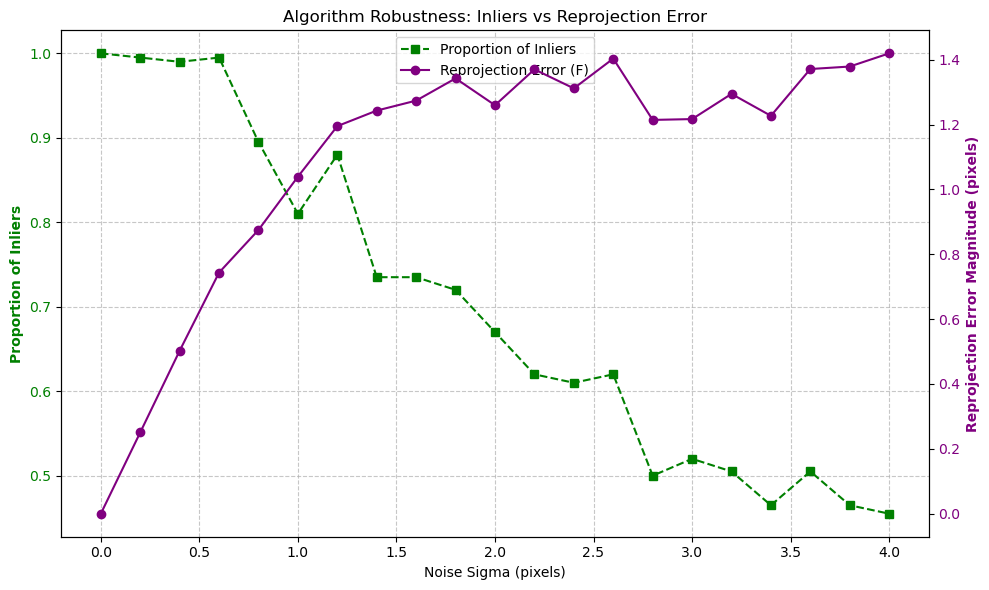

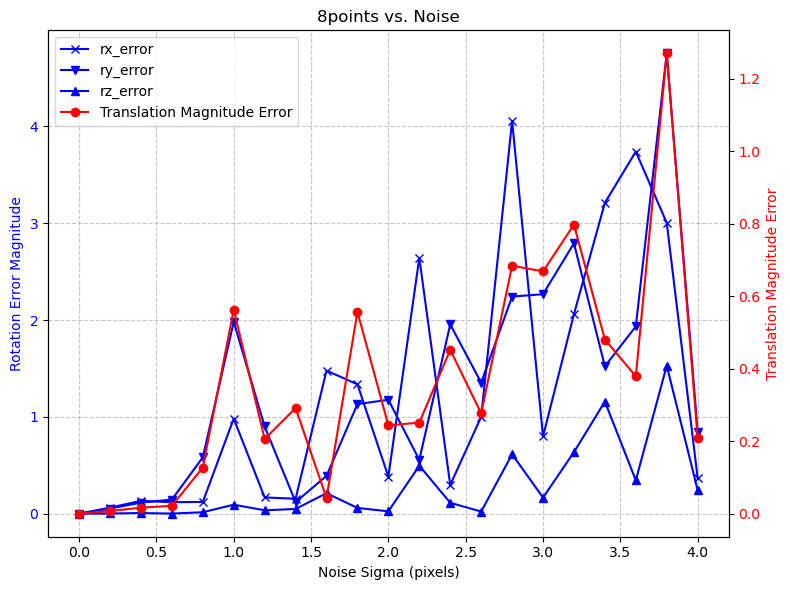

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis (Green - Proportion of Inliers) ---
ax1.set_xlabel('Noise Sigma (pixels)')
ax1.set_ylabel('Proportion of Inliers', color='green', fontweight='bold')

# Plot the inlier proportion data on ax1
line1 = ax1.plot(noise_sigmas, Ransac_mask, label='Proportion of Inliers', marker='s', linestyle='--', color='green')

# Color the left ticks green to match the data
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Purple - Reprojection Error) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Reprojection Error Magnitude (pixels)', color='purple', fontweight='bold')

# Plot the reprojection error data on ax2
line2 = ax2.plot(noise_sigmas, res_F, label='Reprojection Error (F)', marker='o', linestyle='-', color='purple')

# Color the right ticks purple to match the data
ax2.tick_params(axis='y', labelcolor='purple')

# --- Combine Legends ---
# Gather the lines from both axes to make a single unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Placed in 'upper center' so it doesn't block the data paths as easily
ax1.legend(lines, labels, loc='upper center')

# Formatting the overall plot
plt.title('Algorithm Robustness: Inliers vs Reprojection Error')
fig.tight_layout()

# Display the plot
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Left Axis (Blue - Rotation) ---
ax1.set_xlabel('Noise Sigma (pixels)')
ax1.set_ylabel('Rotation Error Magnitude', color='blue')

# Plot the rotation data on ax1
line1 = ax1.plot(noise_sigmas, np.abs(r_est[:,0] - r_true[:,0]), label='rx_error', marker='x', linestyle='-', color="blue")
line2 = ax1.plot(noise_sigmas, np.abs(r_est[:,1] - r_true[:,1]), label='ry_error', marker='v', linestyle='-', color="blue")
line3 = ax1.plot(noise_sigmas, np.abs(r_est[:,2] - r_true[:,2]), label='rz_error', marker='^', linestyle='-', color="blue")

# Color the left ticks blue to match the data
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Red - Translation) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Translation Magnitude Error', color='red')

# Plot the translation data on ax2
line4 = ax2.plot(noise_sigmas, t_error_mag_F, label='Translation Magnitude Error', marker='o', linestyle='-', color="red")

# Color the right ticks red to match the data
ax2.tick_params(axis='y', labelcolor='red')

# --- Combine Legends ---
# Because we have two axes, we have to gather the lines from both to make a single legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Formatting the plot
plt.title('8points vs. Noise')
fig.tight_layout() # Use fig.tight_layout() instead of plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
Nb_pts = 200
noise_sigmas = np.linspace(0, 4, 21)
num_iterations = len(noise_sigmas)

# 1. FIXED: Initialize as 1D arrays matching the length of noise_sigmas
res_H = np.full(num_iterations, np.nan)
Ransac_mask = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
r_est = np.full((num_iterations, 3), np.nan)
r_true = np.full((num_iterations, 3), np.nan)

count = 0
for i in noise_sigmas:
    scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=i, scene_type="planar")
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    plane_dist = 5

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)
    Ransac_mask[count] = np.sum(mask)/mask.shape[0]
    r_true[count, :] = get_angles_from_matrix(R_true)
    r_est[count, :] = get_angles_from_matrix(R_H)
    count +=1



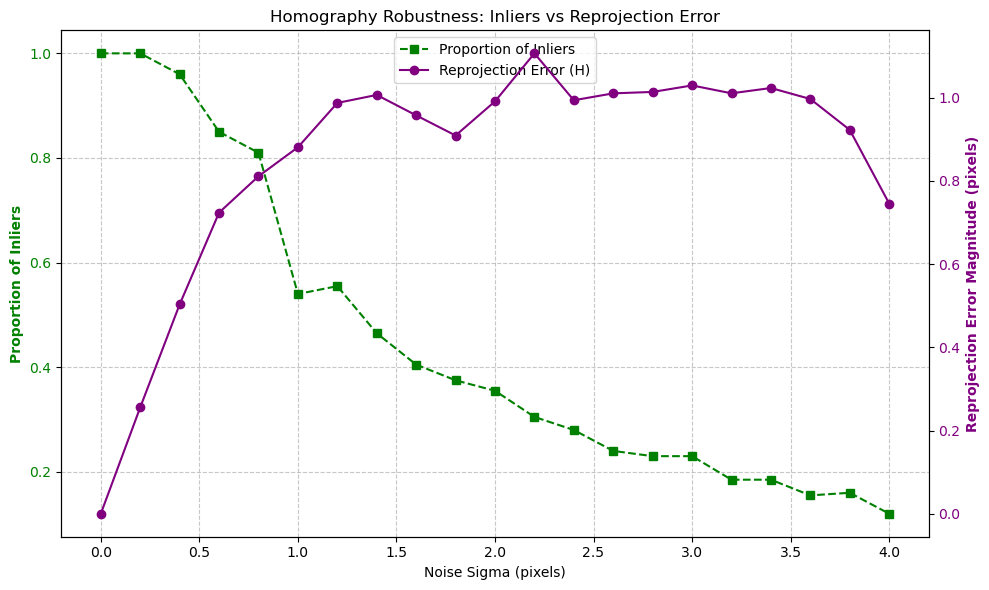

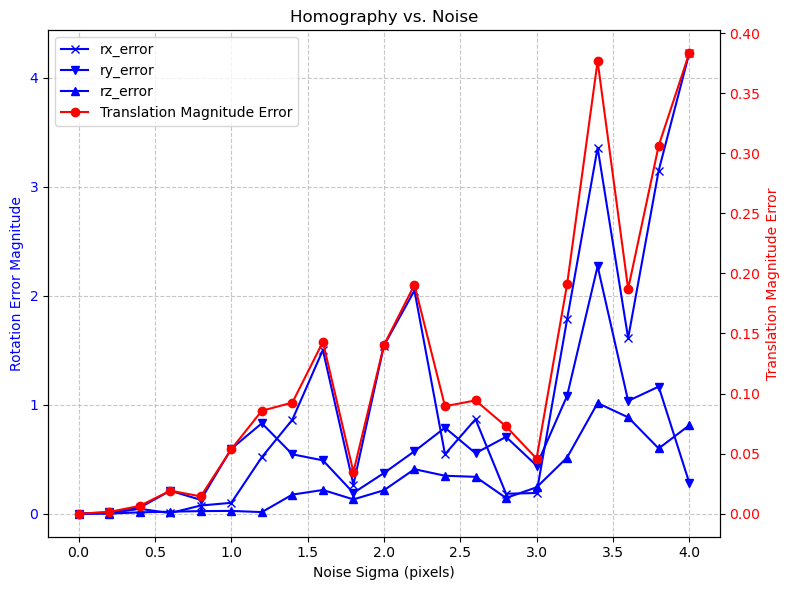

[1.    1.    0.96  0.85  0.81  0.54  0.555 0.465 0.405 0.375 0.355 0.305
 0.28  0.24  0.23  0.23  0.185 0.185 0.155 0.16  0.12 ]


In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis (Green - Proportion of Inliers) ---
ax1.set_xlabel('Noise Sigma (pixels)')
ax1.set_ylabel('Proportion of Inliers', color='green', fontweight='bold')

# Plot the inlier proportion data on ax1
line1 = ax1.plot(noise_sigmas, Ransac_mask, label='Proportion of Inliers', marker='s', linestyle='--', color='green')

# Color the left ticks green to match the data
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Purple - Reprojection Error) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Reprojection Error Magnitude (pixels)', color='purple', fontweight='bold')

# Plot the reprojection error data on ax2
line2 = ax2.plot(noise_sigmas, res_H, label='Reprojection Error (H)', marker='o', linestyle='-', color='purple')

# Color the right ticks purple to match the data
ax2.tick_params(axis='y', labelcolor='purple')

# --- Combine Legends ---
# Gather the lines from both axes to make a single unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Placed in 'upper center' so it doesn't block the data paths as easily
ax1.legend(lines, labels, loc='upper center')

# Formatting the overall plot
plt.title('Homography Robustness: Inliers vs Reprojection Error')
fig.tight_layout()

# Display the plot
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Left Axis (Blue - Rotation) ---
ax1.set_xlabel('Noise Sigma (pixels)')
ax1.set_ylabel('Rotation Error Magnitude', color='blue')

# Plot the rotation data on ax1
line1 = ax1.plot(noise_sigmas, np.abs(r_est[:,0] - r_true[:,0]), label='rx_error', marker='x', linestyle='-', color="blue")
line2 = ax1.plot(noise_sigmas, np.abs(r_est[:,1] - r_true[:,1]), label='ry_error', marker='v', linestyle='-', color="blue")
line3 = ax1.plot(noise_sigmas, np.abs(r_est[:,2] - r_true[:,2]), label='rz_error', marker='^', linestyle='-', color="blue")

# Color the left ticks blue to match the data
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Red - Translation) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Translation Magnitude Error', color='red')

# Plot the translation data on ax2
line4 = ax2.plot(noise_sigmas, t_error_mag_H, label='Translation Magnitude Error', marker='o', linestyle='-', color="red")

# Color the right ticks red to match the data
ax2.tick_params(axis='y', labelcolor='red')

# --- Combine Legends ---
# Because we have two axes, we have to gather the lines from both to make a single legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Formatting the plot
plt.title('Homography vs. Noise')
fig.tight_layout() # Use fig.tight_layout() instead of plt.tight_layout()

# Display the plot
plt.show()

print(Ransac_mask)

# Effect of missmatch points

In [ ]:
outliers = np.arange(0, 0.52, 0.02)
num_iterations = len(outliers)

# 1. FIXED: Initialize as 1D arrays matching the length of noise_sigmas
res_F = np.full(num_iterations, np.nan)
r_est = np.full((num_iterations, 3), np.nan)
r_true = np.full((num_iterations, 3), np.nan)
Ransac_mask = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
count = 0
for i in outliers:
    scene_data = make_scene(n_points=200, outlier_ratio=i, noise_sigma=1)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    
    r_true[count, :] = get_angles_from_matrix(R_true)
    r_est[count, :] = get_angles_from_matrix(R2_hat)
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)
    Ransac_mask[count] = np.sum(mask)/mask.shape[0]
    
    count +=1


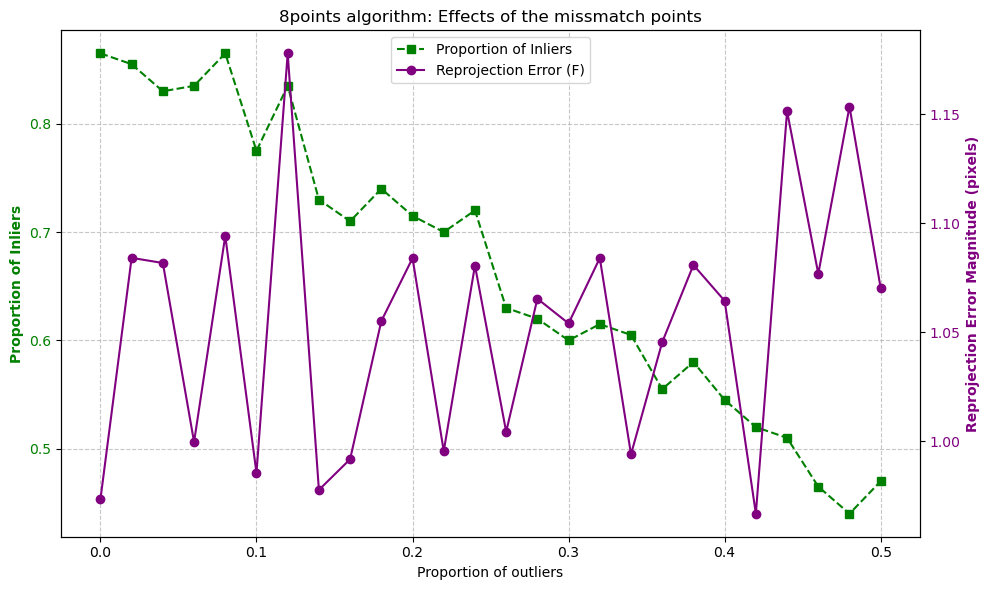

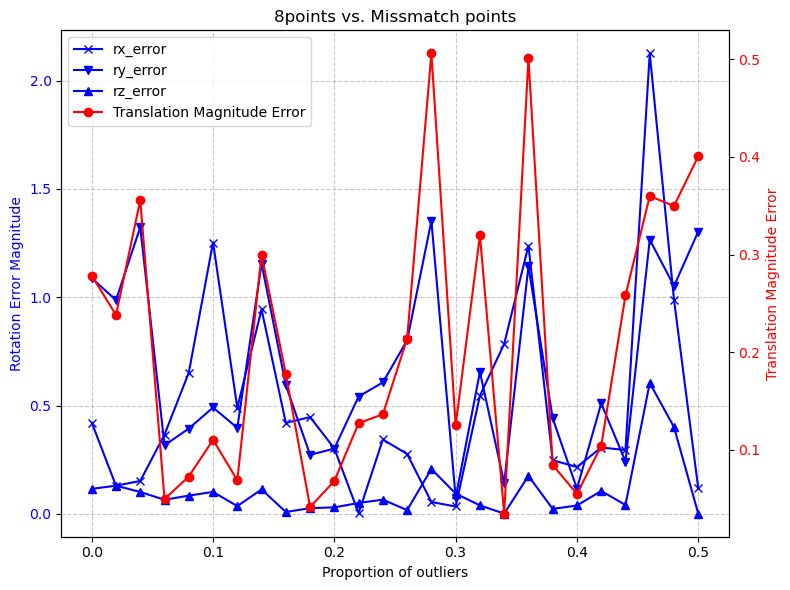

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis (Green - Proportion of Inliers) ---
ax1.set_xlabel('Proportion of outliers')
ax1.set_ylabel('Proportion of Inliers', color='green', fontweight='bold')

# Plot the inlier proportion data on ax1
line1 = ax1.plot(outliers, Ransac_mask, label='Proportion of Inliers', marker='s', linestyle='--', color='green')

# Color the left ticks green to match the data
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Purple - Reprojection Error) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Reprojection Error Magnitude (pixels)', color='purple', fontweight='bold')

# Plot the reprojection error data on ax2
line2 = ax2.plot(outliers, res_F, label='Reprojection Error (F)', marker='o', linestyle='-', color='purple')

# Color the right ticks purple to match the data
ax2.tick_params(axis='y', labelcolor='purple')

# --- Combine Legends ---
# Gather the lines from both axes to make a single unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Placed in 'upper center' so it doesn't block the data paths as easily
ax1.legend(lines, labels, loc='upper center')

# Formatting the overall plot
plt.title('8points algorithm: Effects of the missmatch points')
fig.tight_layout()

# Display the plot
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Left Axis (Blue - Rotation) ---
ax1.set_xlabel('Proportion of outliers')
ax1.set_ylabel('Rotation Error Magnitude', color='blue')

# Plot the rotation data on ax1
line1 = ax1.plot(outliers, np.abs(r_est[:,0] - r_true[:,0]), label='rx_error', marker='x', linestyle='-', color="blue")
line2 = ax1.plot(outliers, np.abs(r_est[:,1] - r_true[:,1]), label='ry_error', marker='v', linestyle='-', color="blue")
line3 = ax1.plot(outliers, np.abs(r_est[:,2] - r_true[:,2]), label='rz_error', marker='^', linestyle='-', color="blue")

# Color the left ticks blue to match the data
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Red - Translation) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Translation Magnitude Error', color='red')

# Plot the translation data on ax2
line4 = ax2.plot(outliers, t_error_mag_F, label='Translation Magnitude Error', marker='o', linestyle='-', color="red")

# Color the right ticks red to match the data
ax2.tick_params(axis='y', labelcolor='red')

# --- Combine Legends ---
# Because we have two axes, we have to gather the lines from both to make a single legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Formatting the plot
plt.title('8points vs. Missmatch points')
fig.tight_layout() # Use fig.tight_layout() instead of plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
Nb_pts = 200
outliers = np.arange(0, 0.52, 0.02)
num_iterations = len(outliers)

res_H = np.full(num_iterations, np.nan)
r_est = np.full((num_iterations, 3), np.nan)
r_true = np.full((num_iterations, 3), np.nan)
Ransac_mask = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
count = 0
for i in outliers:
    scene_data = make_scene(n_points=Nb_pts, outlier_ratio=i, noise_sigma=1, scene_type="planar")
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    plane_dist = 5

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    Ransac_mask[count] = np.sum(mask)
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)
    r_true[count, :] = get_angles_from_matrix(R_true)
    r_est[count, :] = get_angles_from_matrix(R_H)
    count +=1


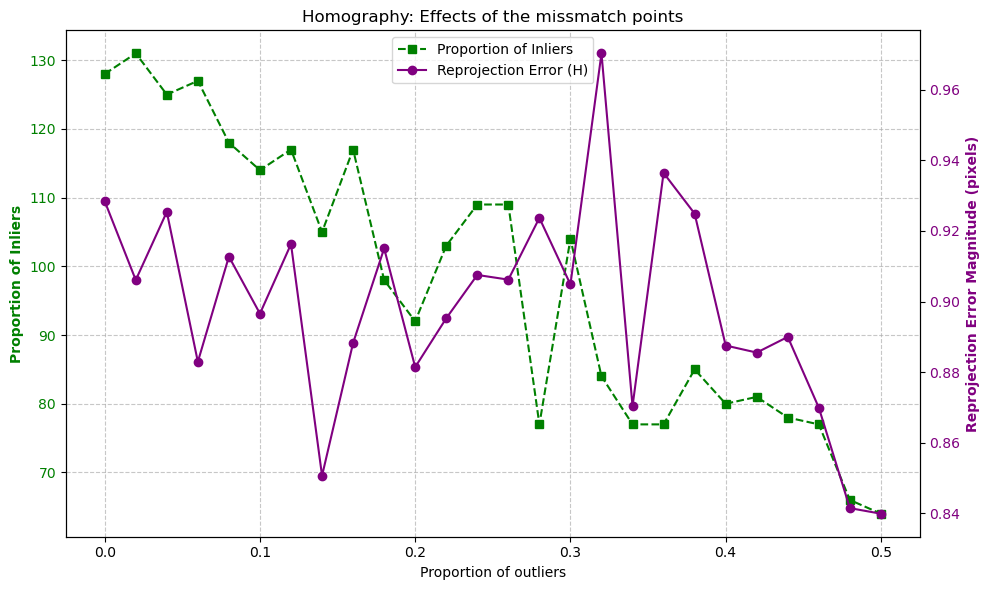

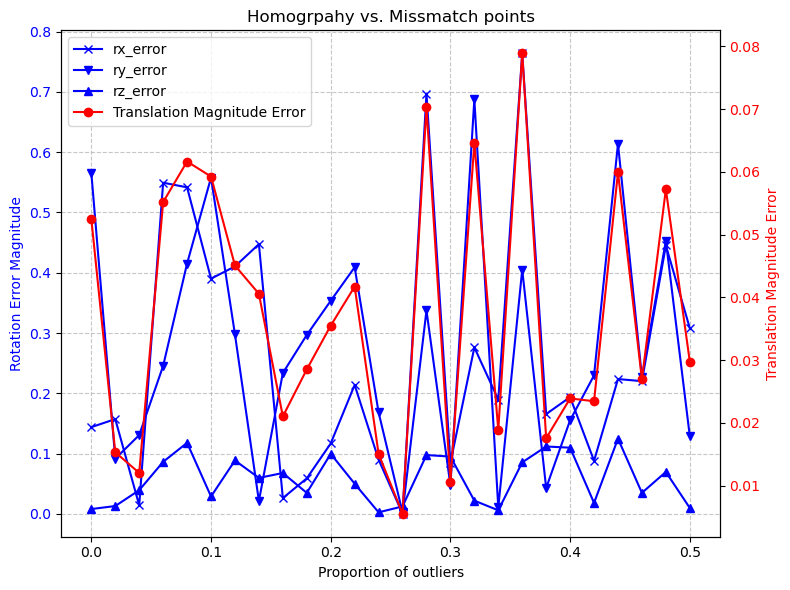

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis (Green - Proportion of Inliers) ---
ax1.set_xlabel('Proportion of outliers')
ax1.set_ylabel('Proportion of Inliers', color='green', fontweight='bold')

# Plot the inlier proportion data on ax1
line1 = ax1.plot(outliers, Ransac_mask, label='Proportion of Inliers', marker='s', linestyle='--', color='green')

# Color the left ticks green to match the data
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Purple - Reprojection Error) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Reprojection Error Magnitude (pixels)', color='purple', fontweight='bold')

# Plot the reprojection error data on ax2
line2 = ax2.plot(outliers, res_H, label='Reprojection Error (H)', marker='o', linestyle='-', color='purple')

# Color the right ticks purple to match the data
ax2.tick_params(axis='y', labelcolor='purple')

# --- Combine Legends ---
# Gather the lines from both axes to make a single unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Placed in 'upper center' so it doesn't block the data paths as easily
ax1.legend(lines, labels, loc='upper center')

# Formatting the overall plot
plt.title('Homography: Effects of the missmatch points')
fig.tight_layout()

# Display the plot
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Left Axis (Blue - Rotation) ---
ax1.set_xlabel('Proportion of outliers')
ax1.set_ylabel('Rotation Error Magnitude', color='blue')

# Plot the rotation data on ax1
line1 = ax1.plot(outliers, np.abs(r_est[:,0] - r_true[:,0]), label='rx_error', marker='x', linestyle='-', color="blue")
line2 = ax1.plot(outliers, np.abs(r_est[:,1] - r_true[:,1]), label='ry_error', marker='v', linestyle='-', color="blue")
line3 = ax1.plot(outliers, np.abs(r_est[:,2] - r_true[:,2]), label='rz_error', marker='^', linestyle='-', color="blue")

# Color the left ticks blue to match the data
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Red - Translation) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Translation Magnitude Error', color='red')

# Plot the translation data on ax2
line4 = ax2.plot(outliers, t_error_mag_H, label='Translation Magnitude Error', marker='o', linestyle='-', color="red")

# Color the right ticks red to match the data
ax2.tick_params(axis='y', labelcolor='red')

# --- Combine Legends ---
# Because we have two axes, we have to gather the lines from both to make a single legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Formatting the plot
plt.title('Homogrpahy vs. Missmatch points')
fig.tight_layout() # Use fig.tight_layout() instead of plt.tight_layout()

# Display the plot
plt.show()


# Analysis of Planar scene

# Histogram of reprojection error (Sampson distance)

In [ ]:
def get_dsamp_H(H, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2]
    d12 = np.sum((p12 - px2) ** 2, axis=0)

    # Backward: H⁻¹ · px2 → px1
    p21 = np.linalg.inv(H) @ h2
    p21 = p21[:2] / p21[2]
    d21 = np.sum((p21 - px1) ** 2, axis=0)
    d_samp = d12 + d21
    return d_samp

Nb_pts = 500
res_H = np.full((1, Nb_pts + 1), np.nan)
scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=1, scene_type="planar")
        
pts3d_vis = scene_data['pts3d']
px1_vis = scene_data['px1']
px2_vis = scene_data['px2']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
plane_dist = 5

ransac_solver_H = RANSAC(
    s=4, 
    score_fct=score_H_RANSAC,
    model_fct=homography, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
H_Ransac, mask = ransac_solver_H.execute_RANSAC()
clean_px1 = px1_vis[:, mask]
clean_px2 = px2_vis[:, mask]
clean_p3d = pts3d_vis[:, mask]
d_samp = get_dsamp_H(H_Ransac, clean_px1, clean_px2)
R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=None,
                                   X_ref=clean_p3d[:, 0])
P2_norm = K@np.hstack((R_H, t_H_norm.reshape(3, 1)))
s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
t_H = s*t_H_norm
P2 = K @ np.hstack((R_H, t_H.reshape(3,1)))
P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
px2_hat, d2 = project_points(pts3D_triag, K, R_H, t_H)
err1 = np.linalg.norm((clean_px1 - px1_hat),axis = 0)
err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
    
# Total symmetric reprojection error
total_squared_errors = err1 + err2



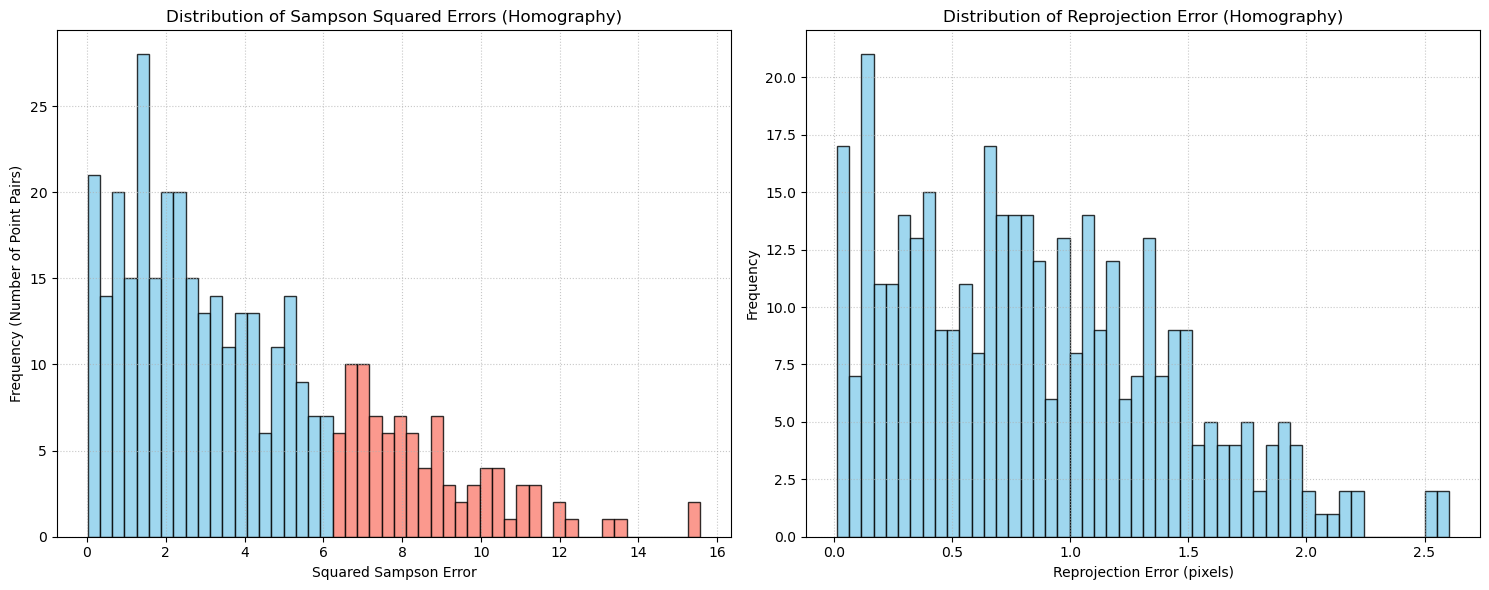

In [ ]:
threshold = 5.99
max_plot_val = threshold * 3

# Create a figure with 1 row and 2 columns, adjusting the width (15) and height (6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Sampson Squared Errors (Left) ---
counts1, bins1, patches1 = ax1.hist(
    np.clip(d_samp, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

# Color the bars that fall past the threshold red
for count, bin_edge, patch in zip(counts1, bins1, patches1):
    if bin_edge > threshold:
         patch.set_facecolor('salmon')
            
# Optional: Draw the decision boundary
# ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax1.set_title("Distribution of Sampson Squared Errors (Homography)")
ax1.set_xlabel("Squared Sampson Error")
ax1.set_ylabel("Frequency (Number of Point Pairs)")
# ax1.legend() # Uncomment if using the axvline above
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: Reprojection Error (Right) ---
counts2, bins2, patches2 = ax2.hist(
    np.clip(total_squared_errors, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

ax2.set_title("Distribution of Reprojection Error (Homography)")
ax2.set_xlabel("Reprojection Error (pixels)")
ax2.set_ylabel("Frequency")
# ax2.legend() 
ax2.grid(True, linestyle=':', alpha=0.7)

# tight_layout prevents the titles and labels from overlapping
plt.tight_layout()
plt.show()

# Test Dispersion

In [ ]:
Nb_pts = 200
r = np.linspace(0.01, 1.0, 100)
num_iterations = len(r)

# 1. FIXED: Initialize as 1D arrays matching the length of noise_sigmas
res_H = np.full(num_iterations, np.nan)
count = 0
for i in r:
    scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=1, scene_type="planar", dispersion=i)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    plane_dist = 5

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    count +=1
    
res_F = np.full(num_iterations, np.nan)
count = 0
for i in r:
    scene_data = make_scene(n_points=Nb_pts, outlier_ratio=0, noise_sigma=1, dispersion=i)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    count +=1


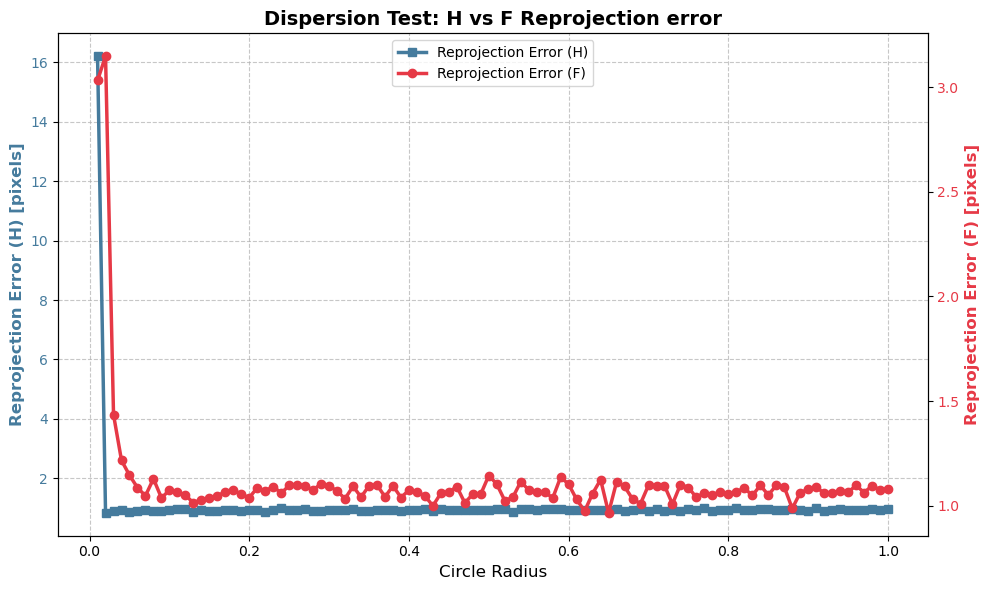

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and the primary axis (Left Y-axis)
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Axis (Blue - Homography Error) ---
ax1.set_xlabel('Circle Radius', fontsize=12)
ax1.set_ylabel('Reprojection Error (H) [pixels]', color='#457B9D', fontweight='bold', fontsize=12)

# Plot the Homography data on ax1
line1 = ax1.plot(r, res_H, label='Reprojection Error (H)', color='#457B9D', linewidth=2.5, marker='s', linestyle='-')

# Color the left ticks blue to match the data
ax1.tick_params(axis='y', labelcolor='#457B9D')
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# --- Right Axis (Red - Fundamental Matrix Error) ---
# Create a second axes that shares the same x-axis
ax2 = ax1.twinx()  

ax2.set_ylabel('Reprojection Error (F) [pixels]', color='#E63946', fontweight='bold', fontsize=12)

# Plot the F-Matrix data on ax2
line2 = ax2.plot(r, res_F, label='Reprojection Error (F)', color='#E63946', linewidth=2.5, marker='o', linestyle='-')

# Color the right ticks red to match the data
ax2.tick_params(axis='y', labelcolor='#E63946')

# --- Combine Legends ---
# Gather the lines from both axes to make a single unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

# Formatting the overall plot
plt.title('Dispersion Test: H vs F Reprojection error', fontsize=14, fontweight='bold')
fig.tight_layout()

# Display the plot
plt.show()

# Planar and Non Planar scene

## Build scene

860
998


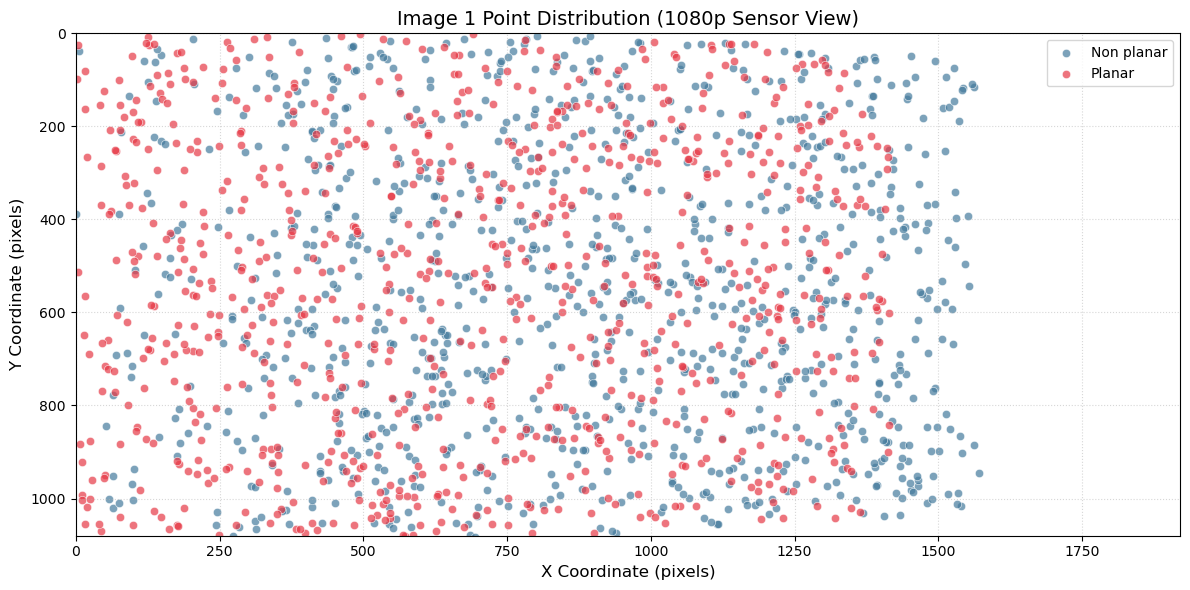

888
1414.7264064182862
851


In [10]:
Nb_points = 4000
scene_data = make_scene(n_points=Nb_points+ 7000, outlier_ratio=0, noise_sigma=1, scene_type="planar",x_range=12, y_range=10)
px1_planar = scene_data['px1']
px2_planar = scene_data['px2']
px3d_planar = scene_data['pts3d']
scene_data = make_scene(n_points=Nb_points - 1800, outlier_ratio=0, noise_sigma=1, x_range=8, y_range=10)
px1_noplanar = scene_data['px1']
px2_noplanar = scene_data['px2']
px3d_noplanar = scene_data['pts3d']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
R_true = scene_data['R_rel']
t_true = scene_data['t_rel']
depth = 5
u_bound = 1800
l_bound = 0
inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
outside_mask = (px1_noplanar[0, :] >= l_bound) | (px1_noplanar[0, :] >= u_bound)
px1_planar = px1_planar[:, inside_mask]
px2_planar = px2_planar[:, inside_mask]
px3d_planar = px3d_planar[:, inside_mask]
px1_noplanar = px1_noplanar[:, outside_mask]
px2_noplanar = px2_noplanar[:, outside_mask]
px3d_noplanar = px3d_noplanar[:, outside_mask]
print(px1_planar.shape[1])
print(px1_noplanar.shape[1])

def plot_planar(px1_planar, px1_noplanar, img_w = 1920, img_h = 1080):
    plt.figure(figsize=(12, 6))

    # Plot Non-Planar points
    plt.scatter(px1_noplanar[0, :], px1_noplanar[1, :], 
                c='#457B9D', label='Non planar', 
                alpha=0.7, edgecolors='white', linewidth=0.5)

    # Plot Planar points
    plt.scatter(px1_planar[0, :], px1_planar[1, :], 
                c='#E63946', label='Planar', 
                alpha=0.7, edgecolors='white', linewidth=0.5)

    # Formatting
    plt.title('Image 1 Point Distribution (1080p Sensor View)', fontsize=14)
    plt.xlabel('X Coordinate (pixels)', fontsize=12)
    plt.ylabel('Y Coordinate (pixels)', fontsize=12)

    # --- LOCKING THE CAMERA SENSOR BOUNDARIES ---
    plt.xlim(0, img_w)       # Locks X from 0 to 1920
    plt.ylim(img_h, 0)       # Locks Y from 1080 to 0 (automatically inverts the Y-axis!)

    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
plot_planar(px1_planar, px1_noplanar)
no_planar_mask = (px1_noplanar[0,:] <= 1400)
print(np.sum(no_planar_mask))
print(np.max(px1_planar[0,:]))
planar_mask = (px1_planar[0,:] <= 1400)
print(np.sum(planar_mask))

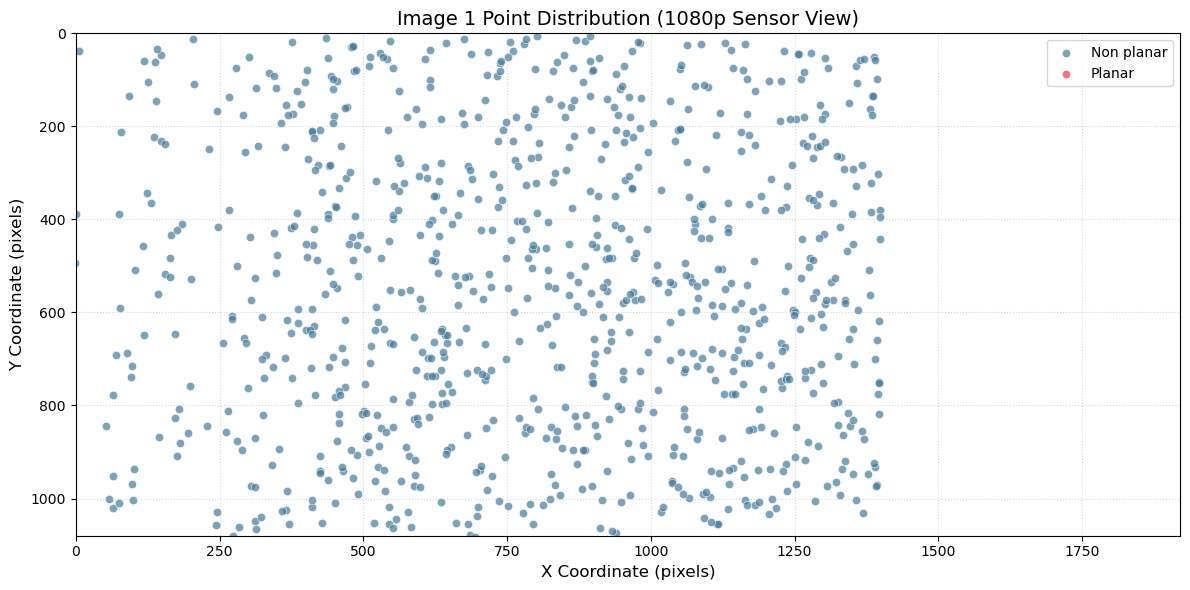

1
2
3
4


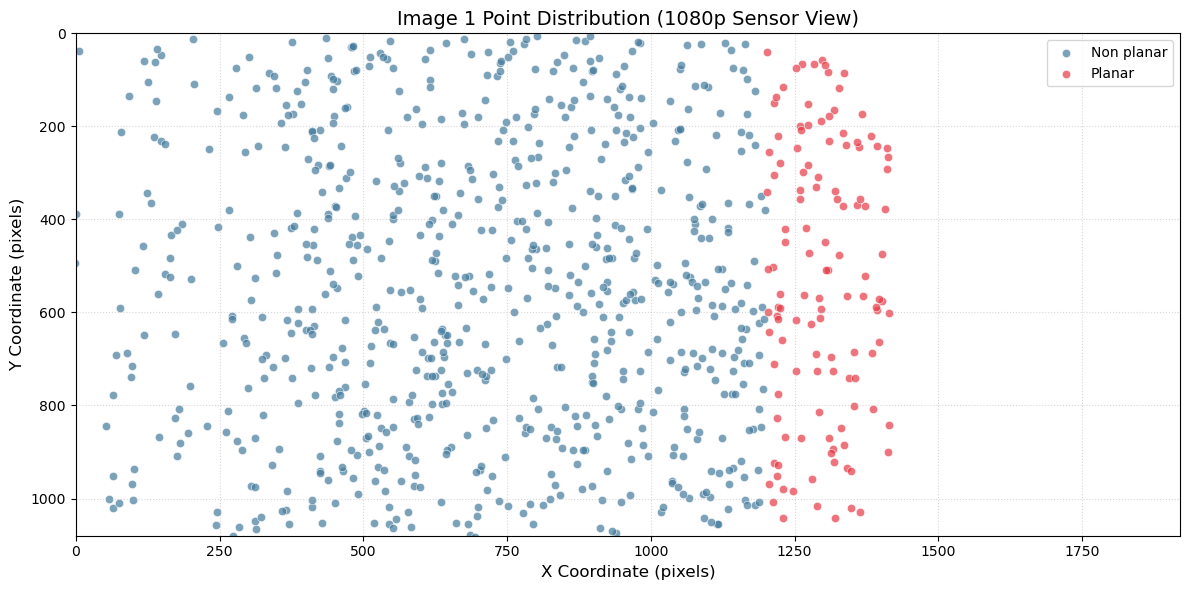

5
6
7
8
9


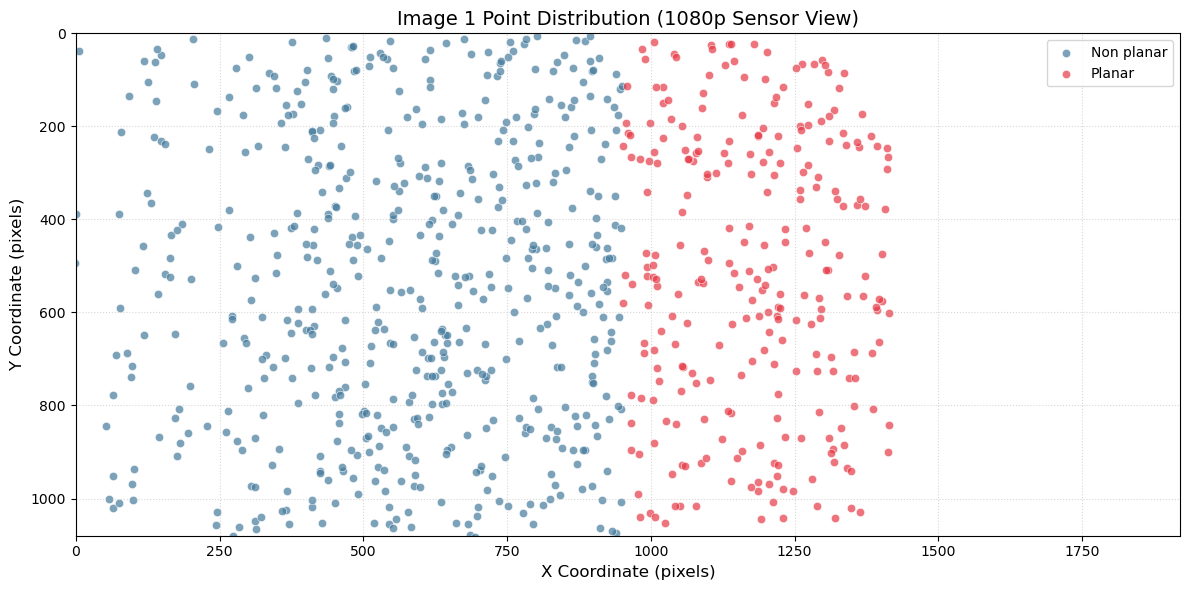

10
11
12
13
14


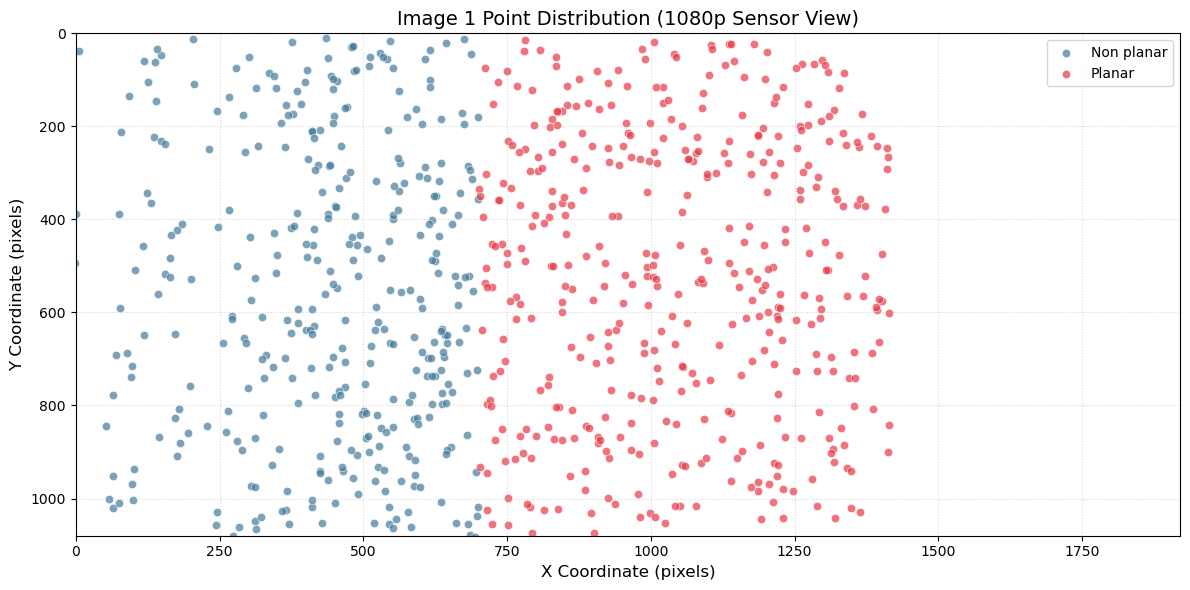

15
16
17
18
19


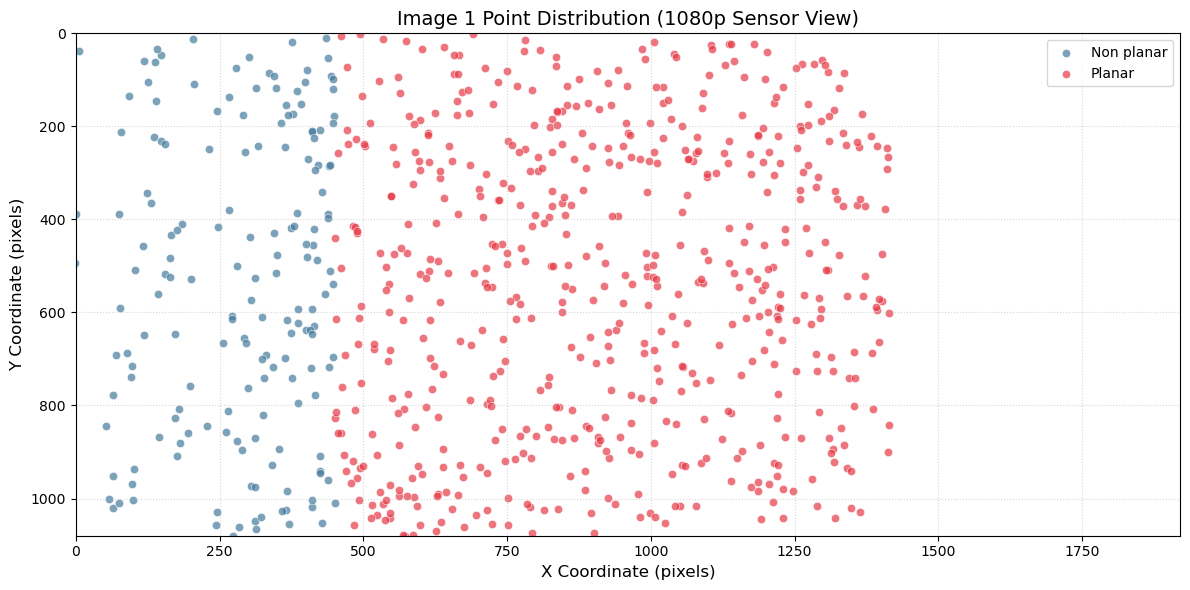

20
21
22
23
24


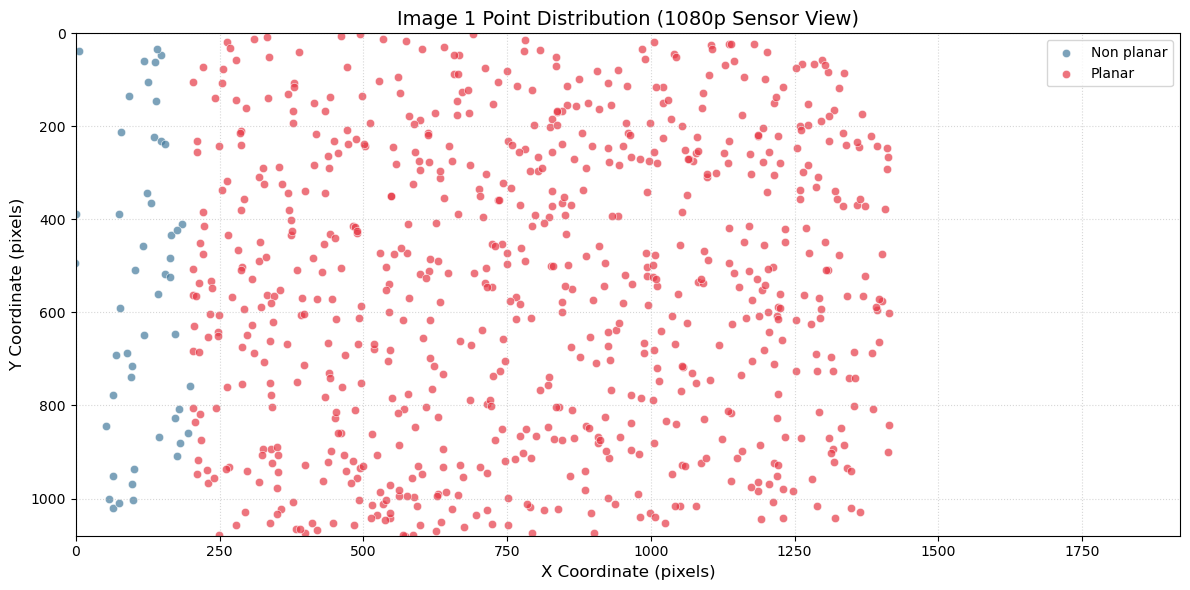

25
26
27


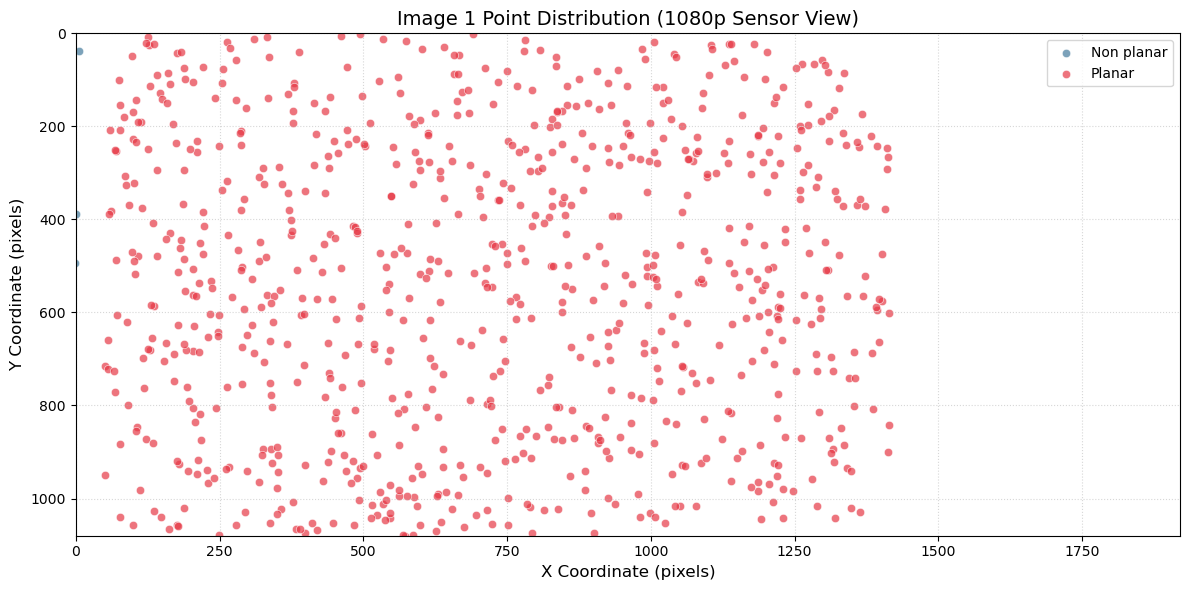

28


In [21]:
Nb_points = 4000
scene_data = make_scene(n_points=Nb_points+ 7000, outlier_ratio=0, noise_sigma=1, scene_type="planar",x_range=12, y_range=10)
px1_planar = scene_data['px1']
px2_planar = scene_data['px2']
px3d_planar = scene_data['pts3d']
scene_data = make_scene(n_points=Nb_points - 1800, outlier_ratio=0, noise_sigma=1, x_range=8, y_range=10)
px1_noplanar = scene_data['px1']
px2_noplanar = scene_data['px2']
px3d_noplanar = scene_data['pts3d']
K = scene_data['K']
R1 = np.eye(3)
t1 = np.zeros((3,1))
R_true = scene_data['R_rel']
t_true = scene_data['t_rel']
window = 50
num_iterations = int(1400 / window)

score_ratio = np.full(num_iterations, np.nan)

res_F = np.full(num_iterations, np.nan)
R_error_F = np.full(num_iterations, np.nan)
t_error_F = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
Repro_error_F = np.full(num_iterations, np.nan)
Ransac_mask_F = np.full(num_iterations, np.nan)
nb_pts_noplan = np.full(num_iterations, np.nan)

res_H = np.full(num_iterations, np.nan)
R_error_H = np.full(num_iterations, np.nan)
t_error_H = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
Repro_error_H = np.full(num_iterations, np.nan)
Ransac_mask_H = np.full(num_iterations, np.nan)
nb_pts_plan = np.full(num_iterations, np.nan)

prop_plan_inlier_H = np.full(num_iterations, np.nan)
prop_noplan_inlier_H = np.full(num_iterations, np.nan)

prop_plan_inlier_F = np.full(num_iterations, np.nan)
prop_noplan_inlier_F = np.full(num_iterations, np.nan)

prop_planar_noplar = np.full(num_iterations, np.nan)

count = 0
for i in range(num_iterations):
    no_planar_mask = (px1_noplanar[0,:] <= 1400 -i*50)
    if i == 0:
        planar_mask = np.full(px1_planar.shape[1], False)
        eps = 0
    else:
        planar_mask = (px1_planar[0,:] > 1400 -i*50)
        eps = None
    curr_px1_planar = px1_planar[:, planar_mask]
    curr_px2_planar = px2_planar[:, planar_mask]
    curr_px3d_planar = px3d_planar[:, planar_mask]
    
    curr_px1_noplanar = px1_noplanar[:, no_planar_mask]
    curr_px2_noplanar = px2_noplanar[:, no_planar_mask]
    curr_px3d_noplanar = px3d_noplanar[:, no_planar_mask]

    # 3. Track the point counts
    nb_pts_plan[count] = curr_px1_planar.shape[1]
    nb_pts_noplan[count] = curr_px1_noplanar.shape[1]
    prop_planar_noplar[count] = nb_pts_plan[count] / (nb_pts_noplan[count] + nb_pts_plan[count]+ 1e-8)
    if (i + 1) % 5 == 0 or i == 0 or i == num_iterations - 1:
        plot_planar(curr_px1_planar, curr_px1_noplanar)
    
    px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
    px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
    px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
    plane_dist = 5
    total_points_this_iteration = px1_combined.shape[1]
    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=eps
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()

    n_plan = int(nb_pts_plan[count])
    
    # Count how many True values are in the planar vs non-planar halves of the mask
    inliers_plan_H = np.sum(mask[:n_plan])
    inliers_noplan_H = np.sum(mask[n_plan:])
    total_inliers_H = np.sum(mask)
    
    # Calculate the proportion of the inlier set
    prop_plan_inlier_H[count] = inliers_plan_H / (total_inliers_H + 1e-8)
    prop_noplan_inlier_H[count] = inliers_noplan_H / (total_inliers_H + 1e-8)

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    # Total symmetric reprojection error
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)
    Ransac_mask_H[count] = np.sum(mask)/total_points_this_iteration

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()

    n_plan = int(nb_pts_plan[count])
    
    inliers_plan_F = np.sum(mask[:n_plan])
    inliers_noplan_F = np.sum(mask[n_plan:])
    total_inliers_F = np.sum(mask)
    
    prop_plan_inlier_F[count] = inliers_plan_F / (total_inliers_F + 1e-8)
    prop_noplan_inlier_F[count] = inliers_noplan_F / (total_inliers_F + 1e-8)

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
        
    # Total symmetric reprojection error
    S_F = score_F(F_Ransac, clean_px1, clean_px2)
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    Ransac_mask_F[count] = np.sum(mask)/total_points_this_iteration
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)
    score_ratio[count] = S_H / (S_H + S_F)
    count +=1
    print(count)

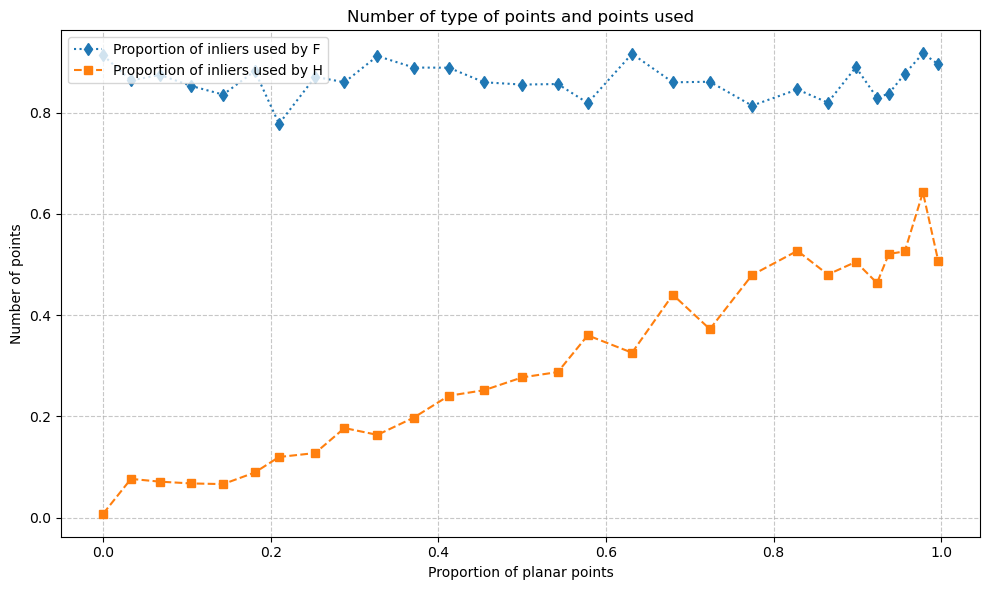

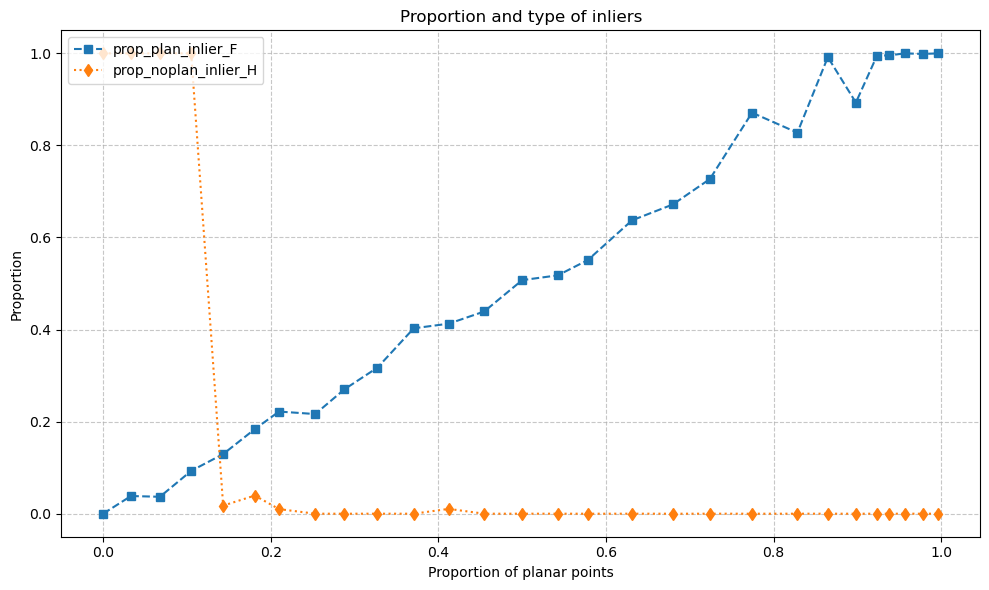

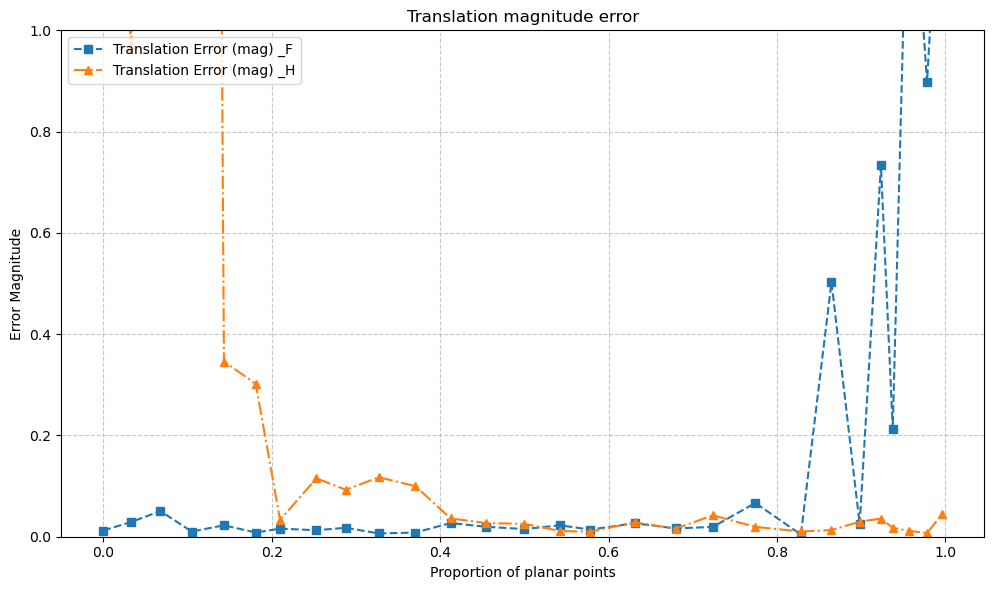

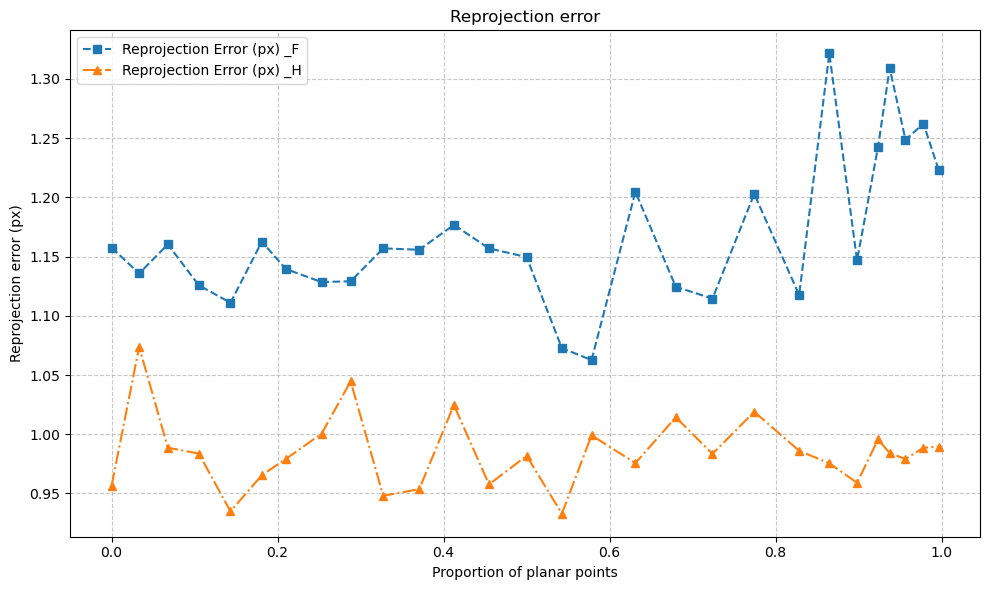

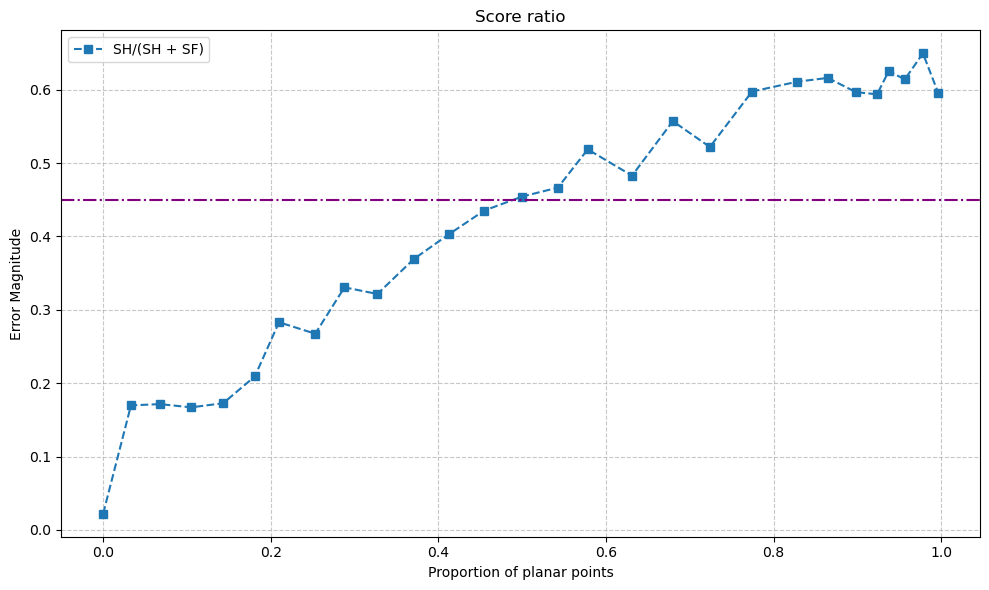

[0.         0.03318078 0.06773823 0.1050175  0.14318976 0.18096357
 0.20983213 0.25304136 0.28795181 0.32722833 0.37064677 0.41235813
 0.45465995 0.5        0.54245881 0.57820513 0.63102999 0.67973856
 0.72391017 0.77423639 0.82833787 0.864682   0.89812332 0.92338177
 0.93742018 0.95646766 0.9781288  0.99641148]


In [23]:
plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas

plt.plot(prop_planar_noplar, Ransac_mask_F, label='Proportion of inliers used by F', marker='d', linestyle=':')
plt.plot(prop_planar_noplar, Ransac_mask_H, label='Proportion of inliers used by H', marker='s', linestyle='--')


# Formatting the plot
plt.title('Number of type of points and points used')
plt.xlabel('Proportion of planar points')
plt.ylabel('Number of points')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas

plt.plot(prop_planar_noplar, prop_plan_inlier_F , label='prop_plan_inlier_F', marker='s', linestyle='--')
plt.plot(prop_planar_noplar, prop_noplan_inlier_H, label='prop_noplan_inlier_H', marker='d', linestyle=':')


# Formatting the plot
plt.title('Proportion and type of inliers')
plt.xlabel('Proportion of planar points')
plt.ylabel('Proportion')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
# Display the plot
plt.show()


plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas
plt.plot(prop_planar_noplar, t_error_mag_F, label='Translation Error (mag) _F', marker='s', linestyle='--')
plt.plot(prop_planar_noplar, t_error_mag_H, label='Translation Error (mag) _H', marker='^', linestyle='-.')

# Formatting the plot
plt.title('Translation magnitude error')
plt.xlabel('Proportion of planar points')
plt.ylabel('Error Magnitude')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.ylim(0, 1)
# Display the plot
plt.show()

plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas
plt.plot(prop_planar_noplar, res_F, label='Reprojection Error (px) _F', marker='s', linestyle='--')
plt.plot(prop_planar_noplar, res_H, label='Reprojection Error (px) _H', marker='^', linestyle='-.')

# Formatting the plot
plt.title('Reprojection error')
plt.xlabel('Proportion of planar points')
plt.ylabel('Reprojection error (px)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas
plt.plot(prop_planar_noplar, score_ratio, label='SH/(SH + SF)', marker='s', linestyle='--')
plt.axhline(y=0.45, color='purple', linestyle='-.')

# Formatting the plot
plt.title('Score ratio')
plt.xlabel('Proportion of planar points')
plt.ylabel('Error Magnitude')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()
print(prop_planar_noplar)

# Thresholding

In [ ]:
noise_sigmas = np.linspace(0, 4, 21)
nb_px = np.arange(50, 151, 100)

# 1. Initialize a 2D array filled with NaNs to store the results
# Rows will represent the noise level (index 'r')
# Columns will represent the point count (index 'c')
ratio_matrix = np.full((len(noise_sigmas), len(nb_px)), np.nan)

# 2. Use enumerate() to easily grab the row and column indices for saving
for r, i in enumerate(noise_sigmas):
    for c, j in enumerate(nb_px):
        
        # FIX: Pass 'j' (the scalar) instead of 'nb_px' (the full array)
        scene_data = make_scene(n_points=j, scene_type="planar", outlier_ratio=0, noise_sigma=i)
        
        pts3d = scene_data['pts3d']
        px1 = scene_data['px1']
        px2 = scene_data['px2']
        
        # --- Evaluate Fundamental Matrix ---
        ransac_F = RANSAC(
            s=8,
            score_fct=score_F_RANSAC,
            model_fct=eight_point,
            px1=px1,
            px2=px2,
            epsilon=None, 
        )
        F, mask_F = ransac_F.execute_RANSAC()
        
        # Safe check: if RANSAC fails, leave the NaN in the matrix and skip to the next loop
        if F is None or mask_F is None or np.sum(mask_F) < 8:
            continue
            
        clean_px1_F   = px1[:, mask_F]
        clean_px2_F   = px2[:, mask_F]
        S_F = score_F(F, clean_px1_F, clean_px2_F)
        
        # --- Evaluate Homography ---
        ransac_H = RANSAC(
            s=4,
            score_fct=score_H_RANSAC,
            model_fct=homography,
            px1=px1,
            px2=px2,
            epsilon=None, 
        )
        H, mask_H = ransac_H.execute_RANSAC()
        
        if H is None or mask_H is None or np.sum(mask_H) < 4:
            continue
            
        clean_px1_H   = px1[:, mask_H]
        clean_px2_H   = px2[:, mask_H]
        S_H      = score_H(H, clean_px1_H, clean_px2_H)
        
        # 3. Calculate the ratio and save it to the matrix
        # Epsilon (1e-12) added to the denominator to prevent division by zero errors
        ratio = S_H / (S_H + S_F)
        ratio_matrix[r, c] = ratio

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thien\AppData\Local\Temp\ipykernel_27212\3689005793.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)


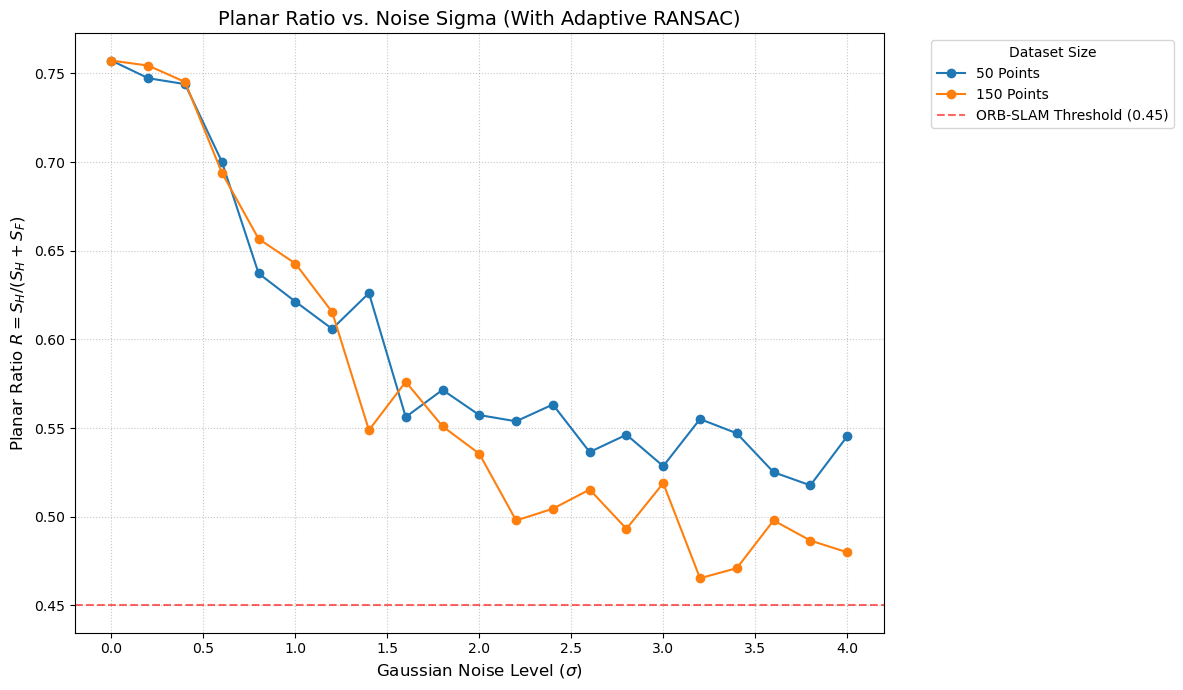

In [ ]:
plt.figure(figsize=(12, 7))

# We iterate through the columns (point counts)
# Slicing [:, 1:] to get 9 curves (skipping the first column of 50 points)
for c in range(0, ratio_matrix.shape[1]):
    label_pts = nb_px[c]
    plt.plot(noise_sigmas, ratio_matrix[:, c], marker='o', label=f'{label_pts} Points')

# Formatting the plot
plt.title("Planar Ratio vs. Noise Sigma (With Adaptive RANSAC)", fontsize=14)
plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)
plt.ylabel("Planar Ratio $R = S_H / (S_H + S_F)$", fontsize=12)

# Adding a horizontal line for the ORB-SLAM decision threshold
plt.axhline(y=0.45, color='r', linestyle='--', alpha=0.6, label='ORB-SLAM Threshold (0.45)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()